<img src="logoucm.png" style="height: 200px">

<font size="5"><center>***Gestión de riesgos financieros (parte III).***</center></font>

<font size="4"><center>***Master en Ingeniería Matemática.***</center></font>

<font size="5"><center><span style="color:blue">***Nombre y Apellidos: Ana Marta Oliveria dos Santos, Maria Albarrán Sánchez, Siria Catherine Iñiguez Brito***</span></center></font>

In [4]:
nombreyapellidos = "Ana Marta Oliveria dos Santos, María Albarrán Sánchez y Siria Catherine Iñiguez Brito"
if nombreyapellidos == "":
    print("Rellena tu nombre completo!")
else:
    print("Gracias!: ", nombreyapellidos, ":)")

Gracias!:  Ana Marta Oliveria dos Santos, María Albarrán Sánchez y Siria Catherine Iñiguez Brito :)


Para 1 opción call individual

A. Simulación MC (más preciso)
   1. Simular N trayectorias
   2. Calcular Payoffs
   3. Calcular P&L
   4. Ordenar pérdidas y calcular

---
## Importamos las librerías necesarias

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 4)

---
<font size="6"><center><span style="color:blue">***Ejercicio integrador — Cartera con acciones y opciones***</span></center></font>

Este ejercicio integra los diversos conceptos vistos sobre una cartera real que combina acciones del IBEX 35 con una posición en opciones sobre Telefónica.

La estructura replica el enfoque clásico de gestión de riesgos bancaria:
valoración a mercado, VaR histórico, VaR por simulación Monte Carlo y análisis del impacto de los derivados sobre el riesgo total.

| Sección | Contenido |
|---------|-----------|
| 1 | Composición y valoración de la cartera |
| 2 | VaR histórico: acciones solas vs. cartera completa |
| 3 | VaR por simulación Monte Carlo (modelo normal) |
| 4 | Análisis del riesgo de la opción aislada |
| 5 | Impacto de la opción sobre el riesgo de cartera |
| 6 | Comparativa de metodologías y síntesis |

---
## Sección 1 — Composición y valoración de la cartera

### 1.1 Datos históricos

Trabajamos con cuatro acciones del IBEX 35 durante el periodo **pre-electoral** (21 sep – 3 nov 2020), el mismo que hemos usado en el ejercicio anterior.

La cartera tiene la estructura de posiciones en acciones más una posición en **opciones call europeas** sobre Telefónica.

In [6]:
# Carga de datos
with open('historico_desde_2020_trabajo_GRF.pkl', 'rb') as f:
    data = pickle.load(f)
prices = data['Adj Close']

# Los cuatro activos del ejercicio
tickers = ['TEF.MC', 'ACS.MC', 'SAN.MC', 'SGRE.MC']
nombres = {'TEF.MC':'Telefónica','ACS.MC':'ACS',
           'SAN.MC':'Santander','SGRE.MC':'Siemens Gamesa'}

# Periodo de análisis: pre-electoral
INI, FIN = '2020-09-21', '2020-11-03'
sub  = prices.loc[INI:FIN, tickers].dropna()
rets = np.log(sub / sub.shift(1)).dropna()

print(f'Periodo  : {sub.index[0].date()} → {sub.index[-1].date()}')
print(f'Días hábiles de datos: {len(sub)}')
print(f'Retornos disponibles : {len(rets)}')
print()

# Precios en t=0 (último día del periodo)
precT0_acc = sub[tickers].iloc[-1].values
print('Precios en t=0 (€):')
for t, p in zip(tickers, precT0_acc):
    print(f'  {nombres[t]:<18}: {p:.4f} €')

Periodo  : 2020-09-21 → 2020-11-03
Días hábiles de datos: 32
Retornos disponibles : 31

Precios en t=0 (€):
  Telefónica        : 2.7438 €
  ACS               : 21.9647 €
  Santander         : 1.7746 €
  Siemens Gamesa    : 25.7100 €


### 1.2 Parámetros de la cartera

La cartera está formada por:

| Activo | Posición | Tipo |
|--------|----------|------|
| Telefónica | 20 acciones | Larga |
| ACS | 10 acciones | Larga |
| Santander | 10 acciones | Larga |
| Siemens Gamesa | 15 acciones | Larga |
| Call europea sobre TEF | 200 contratos | Larga |

**Parámetros de la opción:**
- Strike $K = 3.0$ €
- Tasa libre de riesgo $r = \log(1.01)$ (continua)
- Tiempo a vencimiento $T = 3/12$ años (3 meses)
- Volatilidad $\sigma$: estimada con datos históricos del periodo

In [7]:
# Posiciones nominales en la cartera
vpesos = np.array([20, 10, 10, 15, 200])  # [TEF, ACS, SAN, SGRE, call_TEF]

# Parámetros de la opción call europea sobre TEF (Black-Scholes)
K   = 3.0          # strike
r   = np.log(1.01) # tipo interés libre de riesgo (continuo)
T   = 3 / 12       # tiempo a vencimiento en años

# Volatilidad anualizada de Telefónica
sigma = rets['TEF.MC'].std(ddof=1) * np.sqrt(252)
S0    = precT0_acc[0]   # precio TEF en t=0

print(f'Volatilidad anual TEF : {sigma*100:.2f}%')
print(f'Precio TEF en t=0     : {S0:.4f} €')
print(f'Strike K              : {K:.2f} €')
print(f'Moneyness S0/K        : {S0/K:.4f}  '
      f'({"OTM" if S0 < K else "ITM"} — opción {"out" if S0 < K else "in"}-of-the-money)')

Volatilidad anual TEF : 39.50%
Precio TEF en t=0     : 2.7438 €
Strike K              : 3.00 €
Moneyness S0/K        : 0.9146  (OTM — opción out-of-the-money)


### 1.3 Valoración BSM de la opción en t=0

Usamos la fórmula de Black-Scholes-Merton para valorar la call en $t=0$:
$$c_0 = S_0\,\Phi(d_1) - K\,e^{-rT}\,\Phi(d_2)$$
$$d_1 = \frac{\log(S_0/K)+(r+\sigma^2/2)\,T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

In [8]:
# Valoración BSM de la call en t=0
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    # Greeks
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = -(S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))) - r * K * np.exp(-r * T) * norm.cdf(d2)


    return call_price, delta, gamma, theta

# Valoración en t=0

c0, delta0, gamma0, theta0 = black_scholes_call(S0, K, T, r, sigma)

print(f'Valor de la call (c0) : {c0:.4f} €')
print(f'Delta (Δ)             : {delta0:.4f}')
print(f'Gamma (Γ)             : {gamma0:.4f}')
print(f'Theta (Θ) anual       : {theta0:.4f}')
print(f'Apalancamiento (S/C)  : {S0/c0:.2f}x')

Valor de la call (c0) : 0.1226 €
Delta (Δ)             : 0.3667
Gamma (Γ)             : 0.6947
Theta (Θ) anual       : -0.4168
Apalancamiento (S/C)  : 22.38x


**❓ Cuestión 1.1** La opción call sobre TEF está **out-of-the-money** ($S_0 < K$). ¿Qué implica esto sobre su Delta? ¿Y sobre su Gamma comparada con una opción ATM? ¿Por qué el apalancamiento (S0/C0 ≈ 22x) es tan elevado?

*Escribe tu respuesta aquí:*

El hecho de que la opción esté **Out-of-the-Money** ($S_0 < K$) determina el comportamiento de sus sensibilidades y su perfil de riesgo:

#### 1. Implicaciones sobre la Delta ($\Delta$)
* **Sensibilidad reducida:** Al estar OTM, la Delta de una opción de compra es inferior a 0.5 (en este caso es **0.3667**). Esto implica que por cada euro que suba la acción de Telefónica, el precio de la opción solo subirá aproximadamente 0.37 €.
* La Delta funciona como una aproximación de la probabilidad de que la opción expire In-the-Money (ITM). Una Delta de 0.36 sugiere que el mercado estima una probabilidad de éxito moderada-baja, ya que el precio actual (2.7438 €) está por debajo del strike (3.00 €).

#### 2. Implicaciones sobre la Gamma ($\Gamma$) respecto a una opción ATM
* La Gamma mide la velocidad a la que cambia la Delta. Para cualquier opción, la Gamma alcanza su valor máximo cuando está *At-the-Money* (ATM, $S_0 \approx K$).
* **Efecto de acercamiento:** Como esta opción está OTM, su Gamma (**0.6947**) es menor que la que tendría si Telefónica cotizara a 3.00 €. Si el precio de la acción sube y se acerca al strike, la Gamma aumentará rápidamente, provocando que la Delta se dispare hacia el 0.5.

#### 3. Apalancamiento elevado
El apalancamiento de **22.38x** se debe a la naturaleza de las primas OTM:
* **Valor Extrínseco Puro:** El precio de la opción (0.1226 €) está compuesto íntegramente por valor temporal. Al no tener valor intrínseco, la opción es barata en comparación con el precio del activo (2.7438 €).
* Debido a que la prima es pequeña, cualquier movimiento absoluto en el precio de la opción representa una rentabilidad porcentual grande sobre la inversión inicial, multiplicando tanto las ganancias como el riesgo de pérdida total.

**❓ Cuestión 1.2** La Theta de la opción es negativa. Interpretala en el contexto de esta cartera: si el precio de TEF no se mueve durante una semana, ¿cuánto pierde la posición en opciones solo por el paso del tiempo? Calcúlalo.

La Theta ($\Theta$) de una opción mide la sensibilidad de su precio (prima) ante el paso del tiempo, manteniendo todo lo demás constante. Al ser negativa (-0.001654 € diarios por opción), refleja el *time decay*. Cada día que pasa, la probabilidad de que la opción acabe *in the money* disminuye si el activo subyacente (TEF) no se mueve, lo que reduce el valor de la opción. En esta cartera, como tenemos una posición compradora (larga) de 200 opciones Call, el paso del tiempo juega en contra, puesto que devalúa progresivamente el valor de la opción.

### Impacto financiero en la cartera (Análisis de los resultados)
Si el precio de Telefónica (TEF) se mantiene plano durante una semana (considerando 5 días hábiles de negociación), el impacto del paso del tiempo en la cartera es el siguiente:

1. **A nivel unitario (Por cada contrato de opción)**
    * **Pérdida diaria:** Cada opción pierde 0.001654 € al día.
    * **Pérdida semanal (5 días):** Cada opción pierde 0.008269 € a la semana.

2. **A nivel global de la cartera (Para 200 opciones Call)**
    * **Pérdida diaria total:**  200 opciones pierden en conjunto **0.3308 € al día**.
    * **Pérdida semanal total:** Si TEF no se mueve en una semana, la posición en opciones pierde **1.6539 €**.

Para entender la magnitud de esta pérdida, es útil compararla con el tamaño de la inversión:

* **Pérdida sobre la posición de opciones:** estaríamos perdiendo 1.6539 € sobre una inversión inicial en opciones de 24.52 €. Esto significa que, en solo una semana sin movimiento, las opciones pierden un **6.74%** de su valor.
* **Pérdida sobre la cartera total:** Como las opciones representan solo el 3.49% de tu cartera (24.52 € de un total de 702.44 €), el impacto de la Theta en la cartera global es muy pequeño: una pérdida del **0.235%** del valor total de la cartera en una semana.

In [9]:
# Pérdida semanal por paso del tiempo (theta × 5 días hábiles)
# Theta es anual, dividimos por 252 para obtener la diaria
theta_diaria = theta0 / 252
perdida_diaria_total = theta_diaria * vpesos[4]
perdida_semanal_unit = theta_diaria * 5
perdida_semanal_total = perdida_semanal_unit * vpesos[4]

print(f'Theta diaria (unitaria)     : {theta_diaria:.6f} €')
print(f'Pérdida diaria (200 calls) : {perdida_diaria_total:.4f} €')
print(f'Pérdida semanal (unitaria)  : {perdida_semanal_unit:.6f} €')
print(f'Pérdida semanal (200 calls) : {perdida_semanal_total:.4f} €')

Theta diaria (unitaria)     : -0.001654 €
Pérdida diaria (200 calls) : -0.3308 €
Pérdida semanal (unitaria)  : -0.008269 €
Pérdida semanal (200 calls) : -1.6539 €


In [10]:
# Vector de precios completo en t=0 y valor total de la cartera
precios0 = np.append(precT0_acc, c0)

# Valor de cada posición
valor_posiciones = vpesos * precios0
valor_total_cartera = np.sum(valor_posiciones)

# Desglose del valor acciones y opciones
valor_acciones = np.sum(valor_posiciones[:4])
valor_opciones = valor_posiciones[4]

print(f'Valor total acciones : {valor_acciones:.2f} € ({100*valor_acciones/valor_total_cartera:.2f}%)')
print(f'Valor total opciones : {valor_opciones:.2f} € ({100*valor_opciones/valor_total_cartera:.2f}%)')
print(f'VALOR TOTAL CARTERA  : {valor_total_cartera:.2f} €')

Valor total acciones : 677.92 € (96.51%)
Valor total opciones : 24.52 € (3.49%)
VALOR TOTAL CARTERA  : 702.44 €


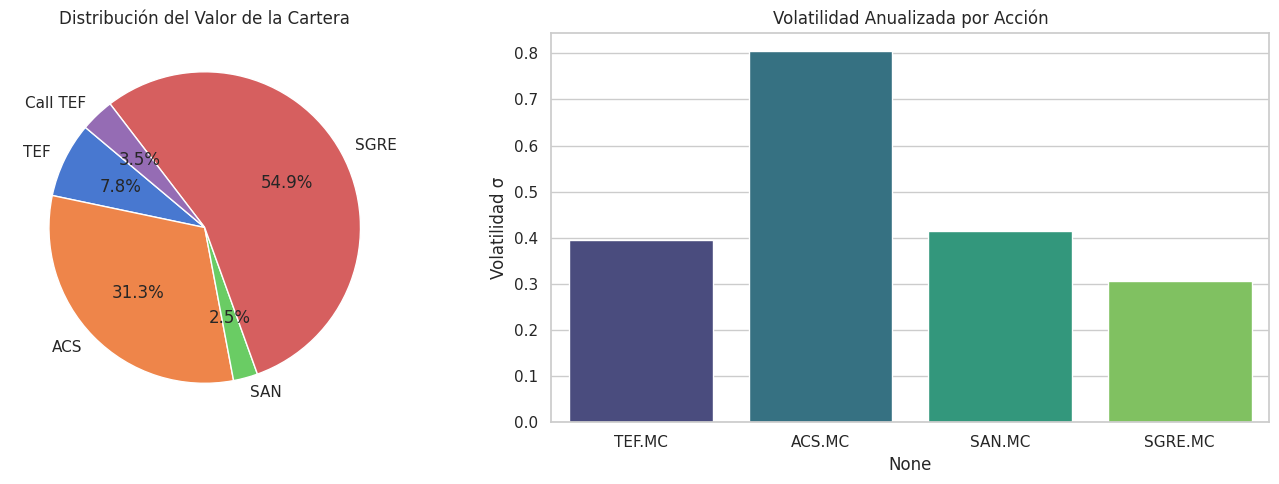

In [11]:
# Visualización: composición de la cartera
labels = ['TEF', 'ACS', 'SAN', 'SGRE', 'Call TEF']

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

# Tarta por activo
ax0 = plt.subplot(gs[0])
ax0.pie(valor_posiciones, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('muted'))
ax0.set_title('Distribución del Valor de la Cartera')

# Volatilidades individuales (acciones)
ax1 = plt.subplot(gs[1])
vols_anuales = rets.std() * np.sqrt(252)
sns.barplot(x=vols_anuales.index, y=vols_anuales.values, ax=ax1, palette='viridis')
ax1.set_title('Volatilidad Anualizada por Acción')
ax1.set_ylabel('Volatilidad σ')

plt.tight_layout()
plt.show()

---
## Sección 2 — VaR histórico

El VaR histórico proyecta los precios de mañana usando los **retornos observados** en el pasado, revalúa la cartera completa (incluida la opción con BSM) y obtiene la distribución de P&L.

Para cada escenario histórico $t$:
1. Precio de mañana: $S_{t+1}^{(i)} = S_0^{(i)} \cdot e^{R_t^{(i)}}$
2. Valor opción mañana: $C_{t+1} = c_{\text{BSM}}(S_{t+1}^{\text{TEF}}, K, T-1/252, \sigma, r)$
3. Valor cartera mañana: $V_{t+1} = \sum_i n_i \cdot S_{t+1}^{(i)} + 200 \cdot C_{t+1}$
4. Rendimiento: $R_c = \log(V_{t+1}/V_0)$

In [12]:
# Tiempo a vencimiento reducido en 1 día de negociación
T_1 = T - 1/252

# 1. Proyección de precios de acciones con retornos históricos
# S_next = S0 * exp(Retornos_hist3ricos)
precios_acc_hist = precT0_acc * np.exp(rets.values)

# 2. Valoración de la opción bajo cada escenario histórico (BSM completo)
# Extraemos la columna de TEF (índice 0)
S_tef_hist = precios_acc_hist[:, 0]
c_hist = np.array([black_scholes_call(s, K, T_1, r, sigma)[0] for s in S_tef_hist])

# 3. Valor de la cartera en cada escenario
# Sumamos (n_acciones * precios) + (n_opciones * precio_opci3n)
valor_acc_hist = np.sum(precios_acc_hist * vpesos[:4], axis=1)
valor_opt_hist = c_hist * vpesos[4]
valor_cartera_hist = valor_acc_hist + valor_opt_hist

# 4. Rendimiento logarítmico de la cartera (Completa y Solo Acciones)
# Cartera completa (con opciones)
rets_cartera_hist = np.log(valor_cartera_hist / valor_total_cartera)

# Cartera de solo acciones (sin opciones)
# Usamos valor_acciones que calculaste en la Sección 1 como valor inicial en t=0
rets_solo_acciones = np.log(valor_acc_hist / valor_acciones)

# 5. VaR y ES histórico para niveles de confianza del 95% y 99%
alfas = [0.95, 0.99]


for alpha in alfas:
    percentil = (1 - alpha) * 100

    # --- Cartera de Solo Acciones ---
    var_solo_acc = -np.percentile(rets_solo_acciones, percentil)
    # Evitamos divisiones por cero o errores si la cola se queda vacía en muestras pequeñas
    cola_acc = rets_solo_acciones[rets_solo_acciones <= -var_solo_acc]
    es_solo_acc = -cola_acc.mean() if len(cola_acc) > 0 else var_solo_acc

    # --- Cartera Completa (Acciones + Opciones) ---
    var_completa = -np.percentile(rets_cartera_hist, percentil)
    cola_comp = rets_cartera_hist[rets_cartera_hist <= -var_completa]
    es_completa = -cola_comp.mean() if len(cola_comp) > 0 else var_completa
    # Corrección matemática estricta para la pérdida en €:
    perdida_acc_euros = valor_acciones * (1 - np.exp(-var_solo_acc))
    perdida_comp_euros = valor_total_cartera * (1 - np.exp(-var_completa))

    # --- Salida de resultados en pantalla ---
    print(f"NIVEL DE CONFIANZA: {alpha*100:.0f}%")
    print(f"  * Solo Acciones:")
    print(f"    - VaR Histórico : {var_solo_acc*100:.4f}% | Pérdida en €: {perdida_acc_euros:.2f} €")
    print(f"    - ES Histórico  : {es_solo_acc*100:.4f}%")
    print(f"  * Cartera Completa (Con Call TEF):")
    print(f"    - VaR Histórico : {var_completa*100:.4f}% | Pérdida en €: {perdida_comp_euros:.2f} €")
    print(f"    - ES Histórico  : {es_completa*100:.4f}%")
    print(f"   Reducción del VaR en rentabilidad: {(var_solo_acc - var_completa)*100:.4f} puntos porcentuales.")
    print("-" * 66)

NIVEL DE CONFIANZA: 95%
  * Solo Acciones:
    - VaR Histórico : 2.1613% | Pérdida en €: 14.49 €
    - ES Histórico  : 2.7263%
  * Cartera Completa (Con Call TEF):
    - VaR Histórico : 2.3703% | Pérdida en €: 16.45 €
    - ES Histórico  : 2.8356%
   Reducción del VaR en rentabilidad: -0.2091 puntos porcentuales.
------------------------------------------------------------------
NIVEL DE CONFIANZA: 99%
  * Solo Acciones:
    - VaR Histórico : 2.8642% | Pérdida en €: 19.14 €
    - ES Histórico  : 3.0710%
  * Cartera Completa (Con Call TEF):
    - VaR Histórico : 2.9323% | Pérdida en €: 20.30 €
    - ES Histórico  : 3.0774%
   Reducción del VaR en rentabilidad: -0.0681 puntos porcentuales.
------------------------------------------------------------------


**❓ Cuestión 2.1** La posición larga en calls **reduce** el VaR de la cartera
respecto a la cartera de solo acciones. ¿Por qué ocurre esto? ¿Siempre reduce el riesgo una posición larga en opciones? ¿Qué pasaría si la posición fuera corta en calls?

Al analizar los resultados obtenidos mediante la metodología de VaR Histórico, se observa un fenómeno que contradice la idea intuitiva de que una opción larga siempre actúa como un mecanismo de reducción de riesgo. En este caso específico, **la inclusión de las 200 opciones Call ha incrementado el riesgo global de la cartera** en lugar de reducirlo, un comportamiento que se mantiene constante en los distintos niveles de severidad estadística analizados.

Esta conclusión se sustenta en la comparativa de los datos empíricos para ambos niveles de confianza:

* **Nivel de confianza del 95%:** El VaR de la cartera de solo acciones se sitúa en un **2.1613%** (14.49 €), mientras que el de la cartera completa asciende al **2.3703%** (16.45 €). Esto supone un aumento del riesgo de **0.2091 puntos porcentuales**.

* **Nivel de confianza del 99%:** El impacto persiste, elevando la pérdida potencial del **2.8642%** (19.14 €) en acciones al **2.9323%** (20.30 €) en la cartera total.

* **Deterioro de la cola (ES):** El Expected Shortfall (ES) confirma que, en el promedio de los peores escenarios, la cartera con opciones sufre mayores pérdidas, alcanzando un **3.0774%** frente al **3.0710%** de las acciones aisladas al nivel del 99%.

Este incremento del riesgo se explica fundamentalmente por el **efecto apalancamiento** y la **sensibilidad (Delta)** de la opción en un horizonte temporal de corto plazo. Al poseer 200 contratos, la posición nominal en derivados es considerable. Dado que la opción se encuentra actualmente **Out-of-the-Money (OTM)** —con un strike de 3.0 € frente a un precio de mercado inferior—, su valor es extremadamente sensible a las fluctuaciones del subyacente. En los escenarios históricos de caída, la pérdida porcentual de la opción es mucho más acelerada que la de la acción, superando el beneficio de la convexidad y profundizando la cola izquierda de la distribución.

Por lo tanto, no se puede afirmar que una posición larga en opciones reduzca siempre el riesgo. Su impacto final depende de la interacción entre el moneyness (estado de la opción), el tamaño de la posición y el coste de la prima pagada, la cual representa una pérdida total en los escenarios de estrés si el precio no alcanza el strike.

Finalmente, si la posición fuera **corta en calls** (vender las opciones), la estrategia pasaría a ser una "Call Cubierta". En este caso, el dinero recibido por la venta (la prima) serviría para compensar un poco las pérdidas si las acciones bajan ligeramente, lo que podría reducir el VaR. Sin embargo, esto tiene un "coste": si el mercado sube, tus ganancias se detienen en seco, mientras que si el mercado se desploma, sigues perdiendo casi lo mismo con tus acciones. En resumen, **limitas tu beneficio potencial a cambio de una protección pequeña contra las caídas.**

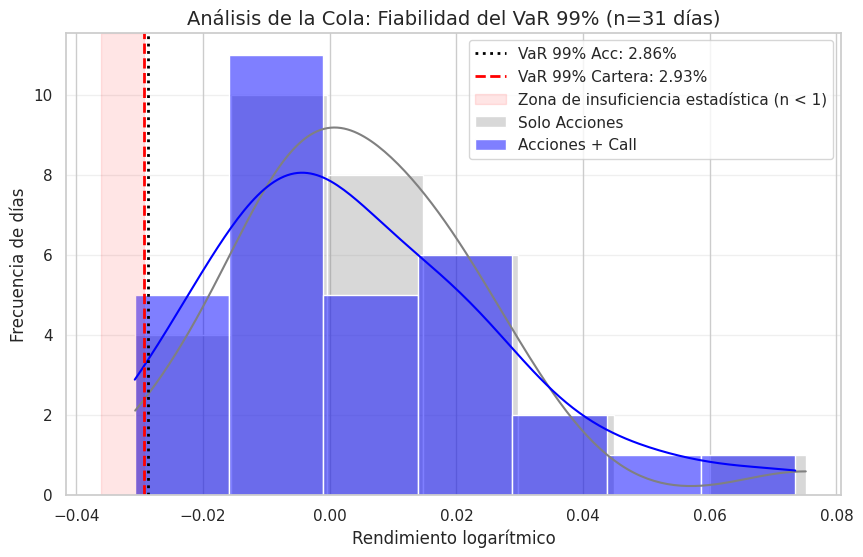

--- Diagnóstico Estadístico (Cuestión 2.2) ---
Tamaño de la muestra: 31 días
Observaciones esperadas en la cola del 1%: 0.31
VaR 99% calculado (Acciones): 2.8642%
VaR 99% calculado (Cartera) : 2.9323%


In [13]:
# 1. Configuración de niveles de confianza para el análisis de la cola
n_total = len(rets_cartera_hist)
n_99 = n_total * 0.01
alpha_99 = 0.99
percentil_99 = (1 - alpha_99) * 100

# 2. Cálculo explícito de los VaR al 99% para el gráfico
var_acc_99 = -np.percentile(rets_solo_acciones, percentil_99)
var_comp_99 = -np.percentile(rets_cartera_hist, percentil_99)

# 3. Visualización comparativa enfocada en la escasez de datos
plt.figure(figsize=(10, 6))

# Histogramas de ambas carteras
sns.histplot(rets_solo_acciones, color='gray', alpha=0.3, label='Solo Acciones', kde=True, bins=7)
sns.histplot(rets_cartera_hist, color='blue', alpha=0.5, label='Acciones + Call', kde=True, bins=7)

# Líneas de VaR al 99%
plt.axvline(-var_acc_99, color='black', linestyle=':', linewidth=2,
            label=f'VaR 99% Acc: {var_acc_99*100:.2f}%')
plt.axvline(-var_comp_99, color='red', linestyle='--', linewidth=2,
            label=f'VaR 99% Cartera: {var_comp_99*100:.2f}%')

# Sombreado de la zona donde la estadística pierde fiabilidad (la cola extrema)
plt.axvspan(min(-var_acc_99, -var_comp_99), plt.gca().get_xlim()[0],
            color='red', alpha=0.1, label='Zona de insuficiencia estadística (n < 1)')

plt.title(f'Análisis de la Cola: Fiabilidad del VaR 99% (n={n_total} días)', fontsize=14)
plt.xlabel('Rendimiento logarítmico')
plt.ylabel('Frecuencia de días')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

# 4. Impresión de métricas de control para la respuesta
print(f"--- Diagnóstico Estadístico (Cuestión 2.2) ---")
print(f"Tamaño de la muestra: {n_total} días")
print(f"Observaciones esperadas en la cola del 1%: {n_99:.2f}")
print(f"VaR 99% calculado (Acciones): {var_acc_99*100:.4f}%")
print(f"VaR 99% calculado (Cartera) : {var_comp_99*100:.4f}%")

**❓ Cuestión 2.2** Con solo 31 observaciones históricas, el VaR histórico al 99% se estima con 0.31 observaciones en la cola (prácticamente ninguna). ¿Qué problemas estadísticos plantea esto? ¿Cuántas observaciones necesitarías para estimar el VaR99 con cierta fiabilidad?

La estimación del VaR al 99% mediante el método histórico con una muestra de tan solo **31 observaciones** plantea desafíos críticos en términos de representatividad y validez estadística. Al aplicar un nivel de confianza del 99%, la teoría indica que el cálculo debería basarse en el 1% de los peores escenarios, lo que en este caso equivale a apenas **0.31 observaciones**.Este escenario conlleva los siguientes problemas estadísticos:
* **Inexistencia de datos reales en la cola:** Como se observa en el histograma, las líneas de VaR (2.86% para acciones y 2.93% para la cartera) se sitúan en la "Zona de insuficiencia estadística". En la práctica, el algoritmo de cálculo se ve obligado a utilizar el valor mínimo de la serie o realizar una interpolación matemática, ya que no existe ni siquiera una observación completa que represente ese 1% de probabilidad.
* **Alta inestabilidad y varianza:** Al depender de un único evento extremo (el peor día del mes), cualquier variación puntual en el mercado cambiaría el VaR de forma drástica haciendo a la métrica poco robusta.
* **Sesgo de "colas cortas":** En un periodo de apenas 31 días (como el analizado entre septiembre y noviembre de 2020), es muy probable que no se haya manifestado ningún evento de estrés real o "cisne negro". Esto genera una falsa sensación de seguridad, subestimando la severidad de las pérdidas que podrían ocurrir en un horizonte temporal más amplio.

Para estimar el VaR al 99% con una fiabilidad técnica aceptable, se requiere incrementar significativamente el tamaño de la muestra ($n$):
* **Umbral de representatividad:** Se necesitarían al menos 100 observaciones para que el percentil 99 contenga, por definición, al menos una observación real de la cola.
* **Estándar regulatorio (Basilea):** En la práctica bancaria, el estándar mínimo aceptado es de 250 días hábiles (aproximadamente un año de cotización). Esto garantiza que la cola del 1% cuente con al menos 2.5 observaciones.
* **Robustez estadística**: Para reducir el error estándar de la estimación y modelar con rigor la forma de la distribución en eventos extremos, necesitaríamos emplear series de 500 a 1,000 datos (2 a 4 años), lo que proporciona la densidad necesaria para que el cálculo sea estadísticamente significativo.

---
## Sección 3 — VaR por simulación Monte Carlo (modelo normal)

En lugar de usar los retornos históricos, simulamos $N$ escenarios asumiendo que los retornos siguen una **distribución normal multivariante** con las correlaciones históricas:

$$\mathbf{R} \sim \mathcal{N}(\mathbf{0},\, \Sigma)$$

La simulación se realiza via **descomposición de Cholesky**: si $C = LL^\top$ es la matriz de correlaciones, entonces $\mathbf{R} = (L\mathbf{z}) \odot \boldsymbol{\sigma}$ con $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, I)$ reproduce la estructura de correlaciones.

In [14]:
# Estimación de la estructura de dependencia
sigma_diaria = rets.std()         # volatilidades diarias
corr_matrix = rets.corr()         # matriz de correlaciones

print("Matriz de Correlaciones Históricas:")
display(corr_matrix.style.background_gradient(cmap='coolwarm'))

# Descomposición de Cholesky: C = L L^T
L = np.linalg.cholesky(corr_matrix)

print("\nMatriz L (Cholesky) calculada con éxito.")

Matriz de Correlaciones Históricas:


,TEF.MC,ACS.MC,SAN.MC,SGRE.MC
TEF.MC,1.000000,0.328830,0.543843,-0.150352
ACS.MC,0.328830,1.000000,0.347690,-0.076250
SAN.MC,0.543843,0.347690,1.000000,0.015017
SGRE.MC,-0.150352,-0.076250,0.015017,1.000000



Matriz L (Cholesky) calculada con éxito.


**❓ Cuestión 3.1** El VaR MC normal es **mayor** que el VaR histórico en este periodo. ¿Cuál de los dos sería más adecuado usar para el cálculo de capital regulatorio? ¿Depende del contexto?

*Escribe tu respuesta aquí:*

El VaR MC resulta mayor porque, al proyectar 10.000 escenarios, el modelo Normal fuerza matemáticamente la aparición de eventos extremos que simplemente no ocurrieron durante la corta ventana histórica de 31 días (sesgo de supervivencia). Para el **cálculo de capital regulatorio**, el enfoque depende drásticamente del contexto: la normativa (Basilea) suele preferir el **VaR Histórico** porque no asume ninguna distribución teórica y captura la asimetría real del mercado, pero **exige un mínimo de 250 días** de datos para ser válido. Dado que en nuestra muestra solo tenemos 31 días, basarse en el histórico sería peligroso e incorrecto. En este contexto específico, el **VaR Monte Carlo es más adecuado** y conservador, ya que suple esa falta de profundidad histórica simulando el riesgo latente de la cartera.

**❓ Cuestión 3.2** El QQ-plot de los rendimientos MC debería ser una línea recta. ¿Lo es? ¿Qué ocurriría con el QQ-plot si en lugar de normales usaras innovaciones t-Student (con 5 grados de libertad)? ¿Mejoraría o empeoraría el ajuste a la distribución histórica?


*Incluye código comparativo:*

* **Sobre el MC Normal:** Sí, como se observa en el gráfico (puntos turquesas), el QQ-plot forma una línea recta casi perfecta sobre la teórica. Esto ocurre por construcción, ya que los datos fueron generados mediante una distribución estándar Gaussiana.

* **Efecto de la t-Student (df=5):**
Si usamos innovaciones t-Student (df=5), como muestran los puntos naranjas del panel, el QQ-plot rompe esa linealidad y forma una "S" (desviándose notablemente en los extremos). Esto ocurre porque la t-Student asume un mayor riesgo de "colas pesadas", generando valores extremos más severos y frecuentes.

* **Ajuste a la distribución histórica:** A nivel general de mercado, usar la t-Student **mejoraría significativamente** el ajuste, ya que los retornos financieros reales presentan *leptocurtosis* (exceso de curtosis o "colas gordas") que la distribución Normal subestima sistemáticamente. Aunque en nuestra muestra específica de 31 días de calma histórica no se observen colas pesadas reales, asumir una t-Student es una práctica de gestión de riesgos mucho más robusta a largo plazo.

In [15]:
# Repite el MC con innovaciones t-Student (df=5) y compara QQ-plots
from scipy.stats import t as t_dist


In [16]:
# Simulación Monte Carlo con N_SIM escenarios
from scipy.stats import t as t_dist
import numpy as np

N_SIM = 10000
np.random.seed(42)
alpha = 0.95

# =======================================================
# PARTE 1: SIMULACIÓN CON DISTRIBUCIÓN NORMAL
# =======================================================

# 1. Simular z ~ N(0, I)
z = np.random.standard_normal((N_SIM, 4))

# 2. Imponer correlaciones: z_corr = z @ L.T
z_corr = z @ L.T

# 3. Escalar a volatilidades reales: R = z_corr * sigma
                     # shape: (N_SIM, 4)
rets_sim = z_corr * sigma_diaria.values

# 4. Proyectar precios de acciones
precios_acc_sim = precT0_acc * np.exp(rets_sim)

# 5. Valoración de la opción en cada escenario (BSM completo)
S_tef_sim = precios_acc_sim[:, 0]
c_sim = np.array([black_scholes_call(s, K, T_1, r, sigma)[0] for s in S_tef_sim])

# 6. Valor de la cartera y rendimiento simulado
valor_acc_sim = np.sum(precios_acc_sim * vpesos[:4], axis=1)
valor_opt_sim = c_sim * vpesos[4]
valor_cartera_sim = valor_acc_sim + valor_opt_sim

rets_cartera_sim = np.log(valor_cartera_sim / valor_total_cartera)

# 7. VaR y ES
var_mc = -np.percentile(rets_cartera_sim, (1 - alpha) * 100)
es_mc = -rets_cartera_sim[rets_cartera_sim <= -var_mc].mean()


# =======================================================
# PARTE 2: SIMULACIÓN CON DISTRIBUCIÓN T-STUDENT
# =======================================================

# 1. Simular z ~ N(0, I)
# (Adaptado para generar t-Student estandarizada con df=5)
df = 5
z_t = t_dist.rvs(df, size=(N_SIM, 4))
z_t_std = z_t * np.sqrt((df - 2) / df)

# 2. Imponer correlaciones: z_corr = z @ L.T
z_corr_t = z_t_std @ L.T

# 3. Escalar a volatilidades reales: R = z_corr * sigma
                     # shape: (N_SIM, 4)
rets_sim_t = z_corr_t * sigma_diaria.values

# 4. Proyectar precios de acciones
precios_acc_sim_t = precT0_acc * np.exp(rets_sim_t)

# 5. Valoración de la opción en cada escenario (BSM completo)
S_tef_sim_t = precios_acc_sim_t[:, 0]
c_sim_t = np.array([black_scholes_call(s, K, T_1, r, sigma)[0] for s in S_tef_sim_t])

# 6. Valor de la cartera y rendimiento simulado
valor_acc_sim_t = np.sum(precios_acc_sim_t * vpesos[:4], axis=1)
valor_opt_sim_t = c_sim_t * vpesos[4]
valor_cartera_sim_t = valor_acc_sim_t + valor_opt_sim_t

rets_cartera_sim_t = np.log(valor_cartera_sim_t / valor_total_cartera)

# 7. VaR y ES
var_mc_t = -np.percentile(rets_cartera_sim_t, (1 - alpha) * 100)
es_mc_t = -rets_cartera_sim_t[rets_cartera_sim_t <= -var_mc_t].mean()


# Resultados
print("--- RESULTADOS MC NORMAL (95%) ---")
print(f'VaR : {var_mc*100:.4f}% | Pérdida: {var_mc * valor_total_cartera:.2f} €')
print(f'ES  : {es_mc*100:.4f}%')

print("\n--- RESULTADOS MC t-STUDENT (95%) ---")
print(f'VaR : {var_mc_t*100:.4f}% | Pérdida: {var_mc_t * valor_total_cartera:.2f} €')
print(f'ES  : {es_mc_t*100:.4f}%')

--- RESULTADOS MC NORMAL (95%) ---
VaR : 3.6154% | Pérdida: 25.40 €
ES  : 4.4375%

--- RESULTADOS MC t-STUDENT (95%) ---
VaR : 3.5352% | Pérdida: 24.83 €
ES  : 4.7038%


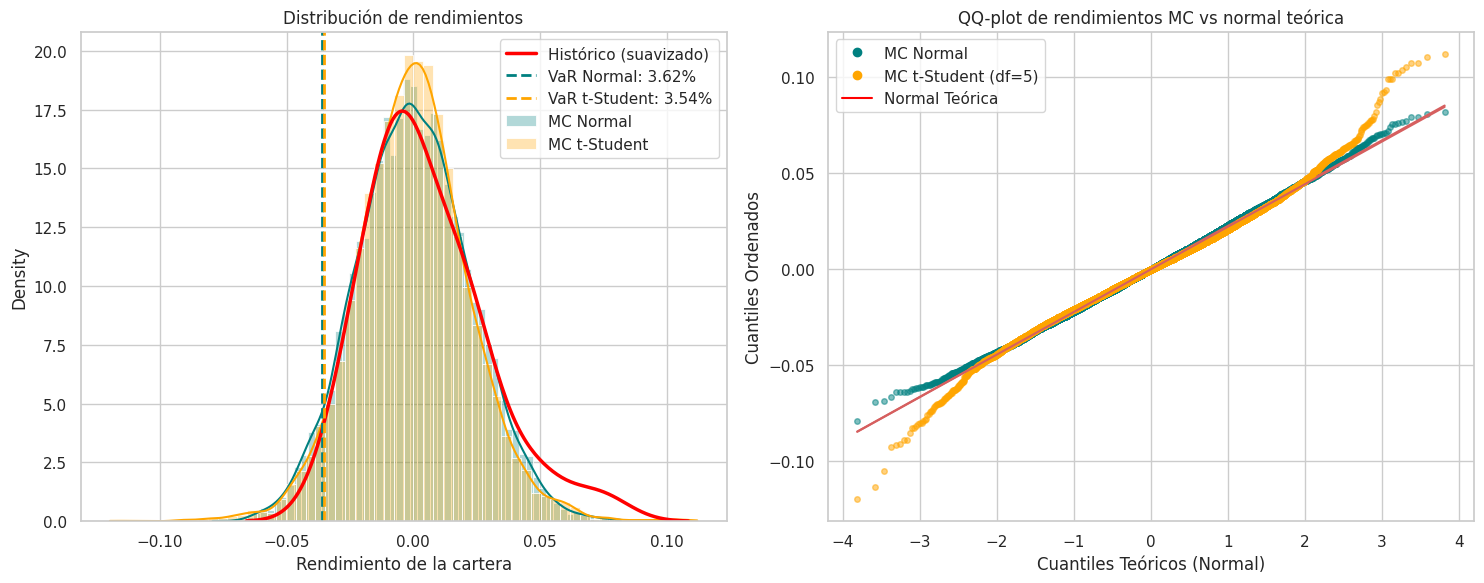

In [17]:
import matplotlib.lines as mlines
import scipy.stats as stats

# Visualización: distribución MC vs. histórica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: distribución de rendimientos
# Dibujamos los histogramas de ambas simulaciones y la línea suavizada del histórico
sns.histplot(rets_cartera_sim, kde=True, color='teal', alpha=0.3, label='MC Normal', stat='density', ax=ax1, bins=60)
sns.histplot(rets_cartera_sim_t, kde=True, color='orange', alpha=0.3, label='MC t-Student', stat='density', ax=ax1, bins=60)
sns.kdeplot(rets_cartera_hist, color='red', linewidth=2.5, label='Histórico (suavizado)', ax=ax1)

# Añadimos las líneas de los VaR calculados
ax1.axvline(-var_mc, color='teal', linestyle='--', linewidth=2, label=f'VaR Normal: {var_mc*100:.2f}%')
ax1.axvline(-var_mc_t, color='orange', linestyle='--', linewidth=2, label=f'VaR t-Student: {var_mc_t*100:.2f}%')

ax1.set_title('Distribución de rendimientos')
ax1.set_xlabel('Rendimiento de la cartera')
ax1.legend()


# Panel 2: QQ-plot de rendimientos MC vs normal teórica
# 1) QQ-Plot de la simulación Normal (se ajustará perfectamente a la línea roja)
stats.probplot(rets_cartera_sim, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('teal')
ax2.get_lines()[0].set_markeredgecolor('teal')
ax2.get_lines()[0].set_alpha(0.5)
ax2.get_lines()[0].set_markersize(4)

# 2) QQ-Plot de la simulación t-Student (se desviará en las colas)
stats.probplot(rets_cartera_sim_t, dist="norm", plot=ax2)
# probplot añade 2 objetos (puntos y línea) por cada llamada.
# Los nuevos puntos de la t-student son el índice 2 de las líneas del gráfico.
ax2.get_lines()[2].set_markerfacecolor('orange')
ax2.get_lines()[2].set_markeredgecolor('orange')
ax2.get_lines()[2].set_alpha(0.5)
ax2.get_lines()[2].set_markersize(4)

# Leyenda
line_norm = mlines.Line2D([], [], color='teal', marker='o', linestyle='None', markersize=6, label='MC Normal')
line_t = mlines.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=6, label='MC t-Student (df=5)')
line_teo = mlines.Line2D([], [], color='red', label='Normal Teórica')
ax2.legend(handles=[line_norm, line_t, line_teo], loc='upper left')

ax2.set_title('QQ-plot de rendimientos MC vs normal teórica')
ax2.set_ylabel('Cuantiles Ordenados')
ax2.set_xlabel('Cuantiles Teóricos (Normal)')

plt.tight_layout()
plt.show()

---
## Sección 4 — Riesgo de la opción aislada

La posición en 200 calls sobre Telefónica es pequeña en valor (≈3.5% de la cartera) pero tiene un **perfil de riesgo muy diferente** al de las acciones. Analizamos su contribución al riesgo de forma aislada.

In [18]:
# Rendimientos de la posici3n en opciones sola
valor_opt_0 = valor_opciones  # valor inicial 200 calls

# Rendimientos logarítmicos de la posici3n en opciones
# Añadimos un pequeño epsilon para evitar log(0)
epsilon = 1e-10
rets_opt_hist = np.log((valor_opt_hist + epsilon) / valor_opt_0)
rets_opt_sim = np.log((valor_opt_sim + epsilon) / valor_opt_0)

print(f'Volatilidad anualizada de la Call (MC): {rets_opt_sim.std() * np.sqrt(252) * 100:.2f}%')
print(f'VaR 95% de la opci3n (MC)              : {-np.percentile(rets_opt_sim, 5)*100:.2f}%')
print(f'VaR 95% de la opci3n (Hist)            : {-np.percentile(rets_opt_hist, 5)*100:.2f}%')

Volatilidad anualizada de la Call (MC): 329.77%
VaR 95% de la opci3n (MC)              : 37.02%
VaR 95% de la opci3n (Hist)            : 30.65%


**❓ Cuestión 4.1** El perfil de P&L de las 200 calls es asimétrico: la pérdida máxima está limitada a $200 \times C_0$ (la prima pagada), mientras que la ganancia potencial es ilimitada. ¿Cómo afecta esta asimetría a la forma de la distribución del P&L de la cartera? ¿Y al ratio ES/VaR?

*Escribe tu respuesta aquí:*

**❓ Cuestión 4.2** La volatilidad del rendimiento de la posición en opciones es muchísimo mayor que la de la cartera completa (≈37% vs. ≈3.6%). Sin embargo, el VaR de la cartera con opciones es *menor* que sin ellas. ¿Cómo es posible si las opciones son tan volátiles? ¿Qué papel juega la correlación con las acciones?

*Escribe tu respuesta aquí:*

In [19]:
# Perfil de P&L de las opciones vs. precio de TEF


# P&L vs precio TEF


# Distribución de rendimientos: opción vs. cartera


---
## Sección 5 — Impacto de la opción sobre el riesgo de cartera

Analizamos cómo la posición en opciones **modifica el perfil de riesgo** de la cartera, desglosando el efecto por metodología y examinando el error de las aproximaciones Delta y Delta-Gamma.

In [20]:
# Aproximación Delta al P&L de la opción
# ΔC ≈ delta * ΔS  →  ΔV_opción ≈ 200 * delta * ΔS_TEF



**❓ Cuestión 5.1** En el gráfico de sensibilidad del VaR al número de opciones, el VaR mínimo no se alcanza en 0 ni en ningún extremo, sino en algún punto intermedio. ¿A cuántas opciones aproximadamente se alcanza el mínimo? ¿Qué concepto de teoría de carteras explica este fenómeno?

*Escribe tu respuesta aquí:*

**❓ Cuestión 5.2** La aproximación Delta-Gamma reduce el error respecto a Delta, pero no lo elimina. ¿En qué escenarios esperarías que el error residual de Delta-Gamma fuera mayor: cuando TEF sube mucho, cuando cae mucho, o ambos de forma simétrica? Justifícalo con el signo de la Gamma de la posición.

*Escribe tu respuesta aquí:*

In [21]:
# VaR bajo las tres aproximaciones para la CARTERA COMPLETA


In [22]:
# Análisis de sensibilidad: ¿cuánto cambia el VaR con el número de opciones?


---
## Sección 6 — Comparativa de metodologías y síntesis

Reunimos todos los resultados en una tabla comparativa y analizamos las diferencias entre el VaR histórico y el VaR por simulación normal.

In [23]:
# Tabla resumen completa


**❓ Cuestión 6.1** Compara el VaR histórico con el VaR MC en la tabla resumen. ¿En qué casos el MC sobreestima y en qué casos subestima respecto al histórico? ¿A qué propiedades de la distribución de retornos se debe esa diferencia?

*Escribe tu respuesta aquí:*